In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as scipy_linalg

plt.rcdefaults()
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']


# Generate the original MG series using the same method described in the paper
def generate_mackey_glass(n_points=2500, tau=17, beta=0.2, gamma=0.1, exponent=10, dt=1.0, initial_value=1.2):
    x = np.ones(n_points + tau + 1, dtype=np.float64) * initial_value
    for t in range(tau, len(x) - 1):
        x_tau = x[t - tau]
        dxdt = beta * x_tau / (1.0 + x_tau ** exponent) - gamma * x[t]
        x[t + 1] = x[t] + dt * dxdt

    return x[tau + 1:tau + 1 + n_points]


def normalize(series, a, b):
    series_min, series_max = np.min(series), np.max(series)

    return a + (series - series_min) / (series_max - series_min) * (b - a)


def make_mask(n_reservoir, mask_seed=0):
    rng = np.random.default_rng(mask_seed)

    return rng.standard_normal((n_reservoir, 1)).astype(np.float64)


# Add noise to the flattened signal injected into the tanh
def add_awgn_to_e(e_clean, snr_db, noise_seed=0):
    e_clean = np.asarray(e_clean, dtype=np.float64)
    if snr_db is None or np.isinf(snr_db):
        return e_clean.copy(), np.zeros_like(e_clean), 0.0
    
    rng = np.random.default_rng(noise_seed)
    signal_power = np.mean(e_clean ** 2)
    noise_power = signal_power / (10.0 ** (snr_db / 10.0))
    noise_std = np.sqrt(noise_power)
    noise = rng.normal(0.0, noise_std, size=e_clean.shape)

    return e_clean + noise, noise, noise_std


def prepare_static_tanh_states(mg_series, n_reservoir=50, mask_seed=0, snr_db=np.inf, noise_seed=0):
    mask = make_mask(n_reservoir, mask_seed)
    masked_matrix_clean = mask @ mg_series.reshape(1, -1)
    e_clean = masked_matrix_clean.reshape(-1, order='F')
    e_noisy, noise, noise_std = add_awgn_to_e(e_clean, snr_db, noise_seed)
    states = np.tanh(e_noisy).reshape(n_reservoir, len(mg_series), order='F')
    masked_matrix_noisy = e_noisy.reshape(n_reservoir, len(mg_series), order='F')

    return states, mask, masked_matrix_clean, masked_matrix_noisy, e_clean, e_noisy, noise, noise_std


def build_previous_state_features(states, time_index, n_previous):
    feature_list = []
    for delay in range(n_previous + 1):
        feature_list.append(states[:, time_index - delay].T)

    return np.concatenate(feature_list, axis=1)


def fit_ridge_multioutput(x_train, y_train, ridge_alpha):
    gram = x_train.T @ x_train
    rhs = x_train.T @ y_train
    penalty = ridge_alpha * np.eye(gram.shape[0])

    return scipy_linalg.solve(gram + penalty, rhs, assume_a='pos', check_finite=False)


def compute_nrmse(y_true, y_pred):
    return np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0) / np.var(y_true, axis=0))


In [2]:
def run_one_noise_seed(mg_clean, future_step_list, n_initial, n_train, n_reservoir, n_previous, ridge_alpha, mask_seed, snr_db, noise_seed):
    states, mask, masked_clean, masked_noisy, e_clean, e_noisy, noise, noise_std = prepare_static_tanh_states(mg_clean, n_reservoir, mask_seed, snr_db, noise_seed)

    train_time_index = np.arange(n_initial, n_initial + n_train)
    x_train = build_previous_state_features(states, train_time_index, n_previous)
    y_train = np.column_stack([mg_clean[train_time_index + step] for step in future_step_list])

    # One matrix solve with multiple target columns is equivalent to training an independent Wout for every horizon.
    weights = fit_ridge_multioutput(x_train, y_train, ridge_alpha)

    test_nrmse = np.zeros(len(future_step_list))
    for h_idx, future_step in enumerate(future_step_list):
        test_time_index = np.arange(n_initial + n_train, len(mg_clean) - future_step)
        x_test = build_previous_state_features(states, test_time_index, n_previous)
        y_test = mg_clean[test_time_index + future_step]
        test_prediction = x_test @ weights[:, h_idx]
        test_nrmse[h_idx] = compute_nrmse(y_test, test_prediction)

    return test_nrmse


def run_static_tanh_experiment(N_TOTAL, N_INITIAL, N_TRAIN, N_RESERVOIR, N_PREVIOUS, RIDGE_ALPHA, MASK_SEED, SNR_DB, NOISE_SEED_LIST, FUTURE_STEP_LIST):
    mg_clean = generate_mackey_glass(n_points=N_TOTAL, tau=17, beta=0.2, gamma=0.1, exponent=10, dt=1.0, initial_value=1.2)
    mg_clean = normalize(mg_clean, 0, 1)

    test_nrmse_array = np.zeros((len(FUTURE_STEP_LIST), len(NOISE_SEED_LIST)))

    for seed_idx, noise_seed in enumerate(NOISE_SEED_LIST):
        test_nrmse = run_one_noise_seed(
            mg_clean, FUTURE_STEP_LIST, N_INITIAL, N_TRAIN, N_RESERVOIR, N_PREVIOUS,
            RIDGE_ALPHA, MASK_SEED, SNR_DB, noise_seed
        )

        test_nrmse_array[:, seed_idx] = test_nrmse

    ddof = 1 if len(NOISE_SEED_LIST) > 1 else 0
    test_mean, test_std = test_nrmse_array.mean(axis=1), test_nrmse_array.std(axis=1, ddof=ddof)

    return test_mean, test_std


def plot_results(snr_db, error_mean, error_std, future_step_list, reference):

    font = 21
    plt.figure(figsize=(8.5, 6))

    plt.plot(future_step_list, reference, marker='o', label='Physical reservoir')

    y, yerr = error_mean, error_std

    label = 'Static tanh (noiseless)' if snr_db is None or np.isposinf(snr_db) else f'Static tanh (SNR = {snr_db} dB)'
    plt.plot(future_step_list, y, marker='o', label=label, color='orange')


    title = 'Noiseless input' if snr_db is None or np.isposinf(snr_db) else f'SNR = {snr_db} dB'
    
    plt.title(title, fontsize=20, fontweight='bold')
    plt.xlabel('Predicted future step', fontsize=font)
    plt.ylabel('NRMSE', fontsize=font)
    plt.xticks(fontsize=font)
    plt.yticks(fontsize=font)
    plt.legend(frameon=0, fontsize=font-1, loc='upper left')
    plt.tight_layout()
    plt.show()




In [3]:
# Published source data from Fig. 4b of the paper
paper_data = np.array([
    0.14977, 0.15814, 0.16705, 0.17656, 0.18595, 0.19371, 0.19835, 0.20030, 0.20090, 0.20063,
    0.20009, 0.19941, 0.19866, 0.19801, 0.19651, 0.19407, 0.19071, 0.18735, 0.18586, 0.18892,
    0.19962, 0.21902, 0.24509, 0.27428, 0.30271, 0.32706, 0.34457, 0.35473, 0.35850, 0.35730,
    0.35309, 0.34773, 0.34330, 0.34067, 0.33957, 0.33857, 0.33759, 0.33513, 0.33080, 0.32589,
    0.32496, 0.33515, 0.36203, 0.40612, 0.46225, 0.52222, 0.57799, 0.62254, 0.65087, 0.66095
], dtype=np.float64)

### Set parameters and run the experiments


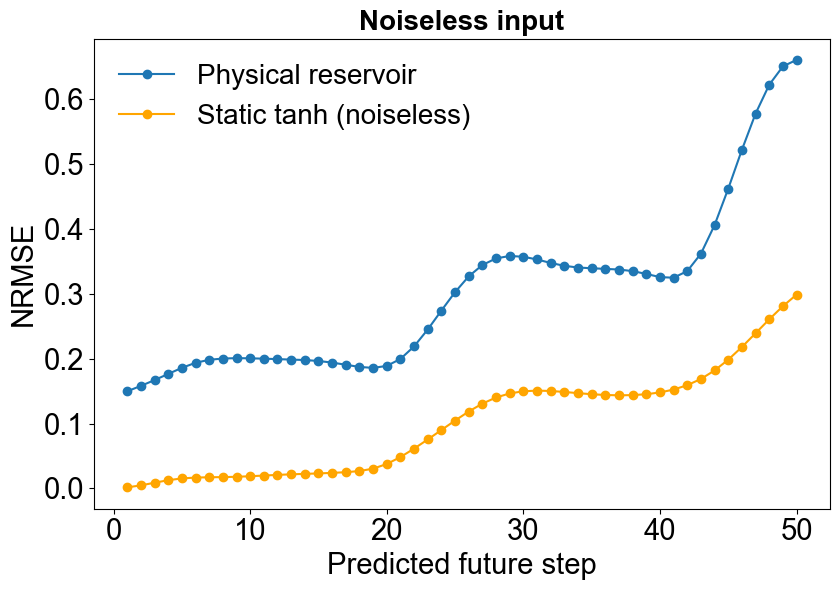

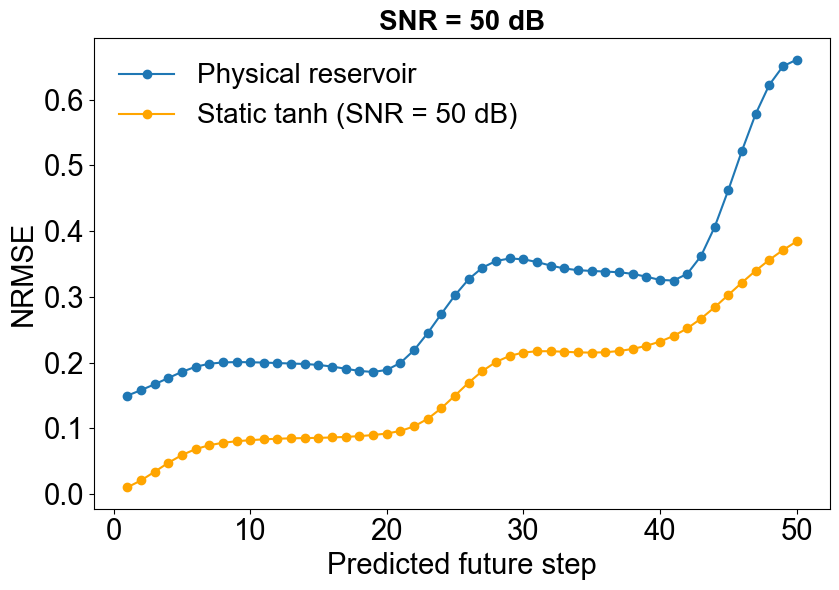

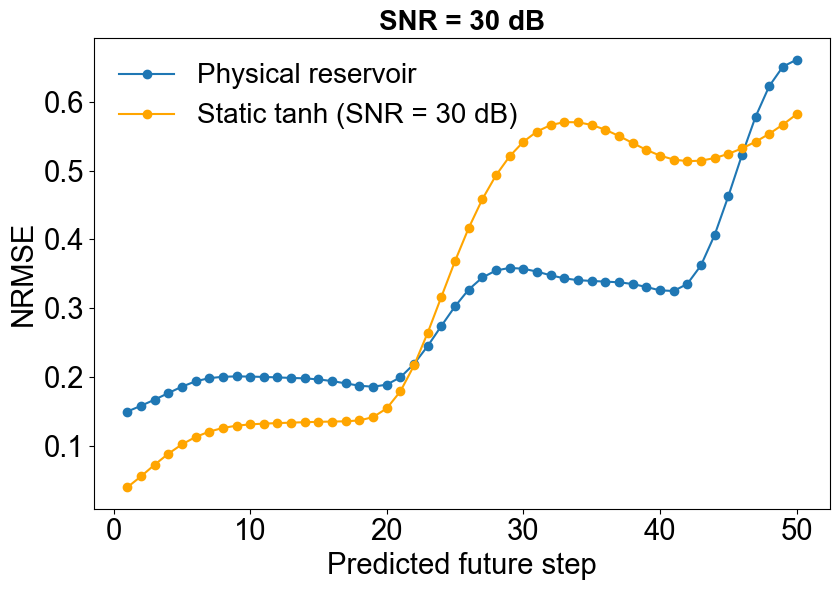

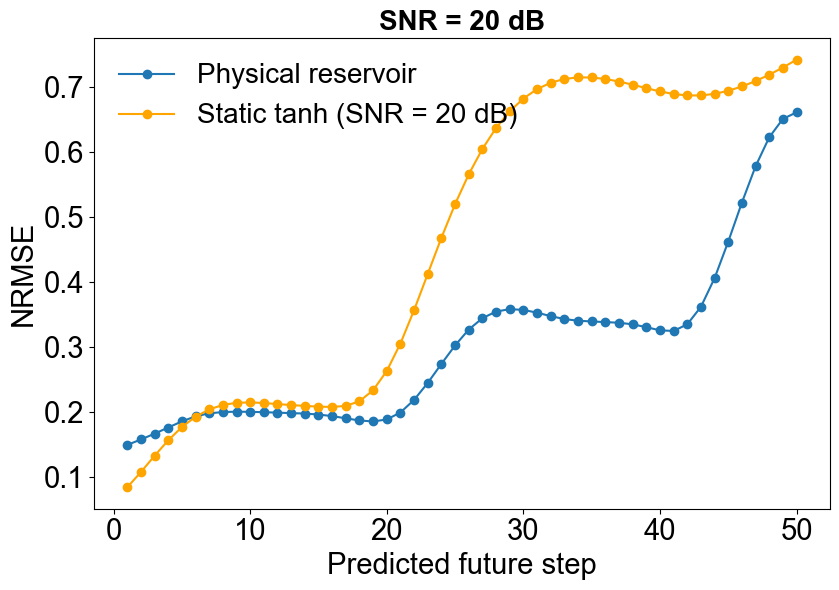

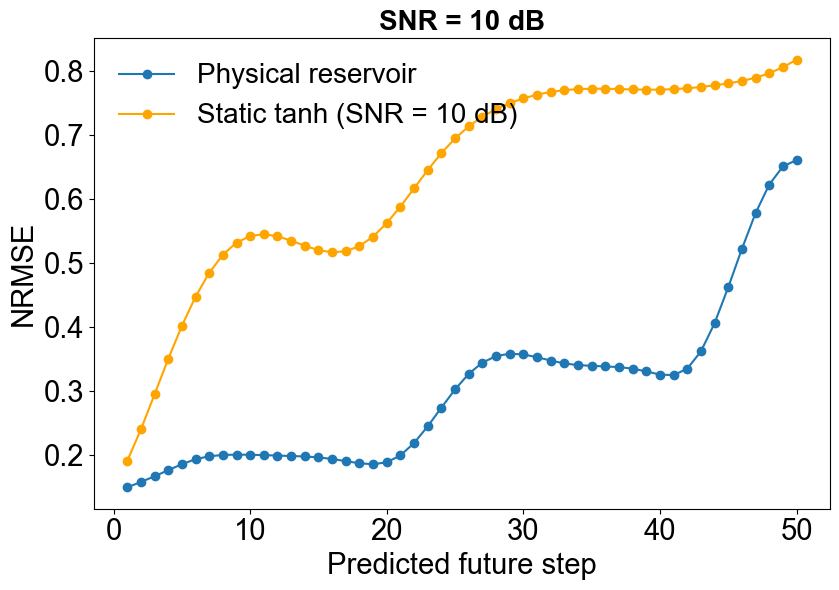

In [4]:
N_TOTAL = 2500
N_INITIAL = 600
N_TRAIN = 1200
N_RESERVOIR = 50
N_PREVIOUS = 30
MASK_SEED = 0
NOISE_SEED_LIST = [0, 1, 2, 3, 4]
FUTURE_STEP_LIST = np.arange(1, 51)

SNR_DB_LIST = [np.inf, 50, 30, 20, 10]
RIDGE_ALPHA_LIST = [1e-4, 1e-2, 1e0, 1e1, 1e2]

for i in range(len(SNR_DB_LIST)):
    SNR_DB = SNR_DB_LIST[i]
    RIDGE_ALPHA = RIDGE_ALPHA_LIST[i]

    test_mean, test_std = run_static_tanh_experiment(
        N_TOTAL, N_INITIAL, N_TRAIN, N_RESERVOIR, N_PREVIOUS,
        RIDGE_ALPHA, MASK_SEED, SNR_DB, NOISE_SEED_LIST, FUTURE_STEP_LIST
    )

    plot_results(SNR_DB, test_mean, test_std, FUTURE_STEP_LIST, paper_data)


